<a href="https://colab.research.google.com/github/chiangjasmine2026/ADALL_github/blob/main/ADALL%20Project%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install -U \
  scikit-learn==1.8.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 26.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
print("Setup complete")

Setup complete


In [ ]:
import sklearn
print("scikit-learn version:", sklearn.__version__)


scikit-learn version: 1.8.0


In [ ]:
# Example: Replace this with the raw URL of your GitHub file
github_raw_url = 'https://raw.githubusercontent.com/chiangjasmine2026/ADALL_github/refs/heads/main/diabetes_012_health_indicators_BRFSS2015.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("Successfully loaded data from GitHub!")
    display(df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")

Successfully loaded data from GitHub!


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
import pandas as pd
import numpy as np
from io import StringIO
# ---------------------------
# Generate a full dataset profile
# ---------------------------
buffer = StringIO()

# dtypes
buffer.write("=== DTYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

# numeric describe
buffer.write("=== NUMERIC DESCRIBE ===\n")
buffer.write(df.describe().to_string())
buffer.write("\n\n")

# categorical describe
buffer.write("=== CATEGORICAL DESCRIBE ===\n")
try:
    buffer.write(df.describe(include='object').to_string())
except:
    buffer.write("No categorical columns")
buffer.write("\n\n")

# null summary
buffer.write("=== NULL SUMMARY ===\n")
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
buffer.write(null_summary.to_string())
buffer.write("\n\n")

# unique cardinality
buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")
buffer.write(df.nunique().to_frame("unique_count").to_string())
buffer.write("\n\n")

# correlation matrix
buffer.write("=== CORRELATIONS (NUMERIC ONLY) ===\n")
buffer.write(df.corr(numeric_only=True).round(3).to_string())
buffer.write("\n\n")

# value counts for categoricals
buffer.write("=== VALUE COUNTS (TOP 20 PER CATEGORICAL COLUMN) ===\n")
cat_cols = df.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    for col in cat_cols:
        buffer.write(f"\nColumn: {col}\n")
        vc = df[col].value_counts().head(20)
        buffer.write(vc.to_string())
        buffer.write("\n")
else:
    buffer.write("No categorical columns\n")
buffer.write("\n")

# --------- FIXED OUTLIER COMPUTATION (NO BOOLEANS) ---------
buffer.write("=== OUTLIER SUMMARY (IQR METHOD) ===\n")
num_cols = df.select_dtypes(include=['number']).columns  # exclude booleans
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).sum()
buffer.write(outliers.to_string())
buffer.write("\n\n")

# leakage scan: columns with all unique values
buffer.write("=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n")
leak_cols = df.columns[df.nunique() == len(df)]
buffer.write(str(list(leak_cols)))
buffer.write("\n\n")

# shape, duplicates, constant cols
buffer.write("=== SHAPE / DUPLICATES / CONSTANT COLUMNS ===\n")
dup_count = df.duplicated().sum()
constant_cols = df.columns[df.nunique() == 1].tolist()
buffer.write(f"Rows: {len(df)}, Columns: {df.shape[1]}\n")
buffer.write(f"Duplicate rows: {dup_count}\n")
buffer.write(f"Constant columns: {constant_cols}\n\n")

# Final text
payload_text = buffer.getvalue()

print(payload_text)


=== DTYPES ===
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64

=== NUMERIC DESCRIBE ===
        Diabetes_012         HighBP       HighChol      CholCheck            BMI         Smoker         Stroke  HeartDiseaseorAttack   PhysActivity         Fruits        Veggies  HvyAlcoholConsump  AnyHealthcare    NoDocbcCost        GenHlth       MentHlt

In [ ]:
from google.colab import userdata
from openai import OpenAI
# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(
    api_key=api_key,
)

In [ ]:
# response = client.responses.create(
#     model="gpt-5-mini",
#     instructions="""
# You are an expert data scientist with extensive knowledge of tree-based models.
# Always justify recommendations using reasoning trace based ONLY on the dataset profile.
# """,
#     input=f"""
# Dataset info: {payload_text}\n
# Questions:\n
# 1. Based on the dataset profile, what data quality issues should be resolved before modelling?
# Provide a priority list and justify each item. \n
# 2. Which columns appear redundant, correlated, or likely to cause leakage?
# Explain why each is problematic. \n
# Next: Provide a python script to handle the identified issues.
# Define one helper function for each issue.
# Then define a wrapper function that calls these helper with true false option as user choice
# Provide a single line of code to run the overall wrapper function.
# Do not encode categorical columns or model first.
# """)
# print(response.output_text)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

def check_missing_and_duplicates(df, verbose=True):
    """Check for missing values and duplicates. Returns df unchanged but raises if missing present when verbose=True."""
    missing = df.isnull().sum()
    total_missing = missing.sum()
    if verbose:
        print("Total missing values:", int(total_missing))
        if total_missing > 0:
            print(missing[missing > 0])
        dup_count = df.duplicated(keep=False).sum()
        print("Duplicate rows count:", int(dup_count))
    return df

def drop_constant_columns(df, verbose=True):
    """Drop any constant columns (zero variance)."""
    nunique = df.nunique(dropna=False)
    const_cols = nunique[nunique <= 1].index.tolist()
    if verbose:
        print("Constant columns to drop:", const_cols)
    if const_cols:
        df = df.drop(columns=const_cols)
    return df

def remove_highly_correlated(df, target_col='target', threshold=0.95, verbose=True):
    """
    Remove highly correlated features (pairwise abs corr > threshold).
    For each correlated pair, keep the column with larger absolute Pearson correlation with target_col.
    """
    # work on numeric columns only
    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col not in numeric:
        raise ValueError("target_col must be numeric and present in df")
    features = [c for c in numeric if c != target_col]
    corr = df[features].corr().abs()

    to_drop = set()
    # precompute abs correlation with target
    abs_corr_with_target = df[features].corrwith(df[target_col]).abs()

    # iterate upper triangle pairs
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            c1 = cols[i]; c2 = cols[j]
            if corr.iloc[i, j] > threshold:
                # compare correlation with target; if equal use variance as tie-breaker (drop the lower variance)
                corr1 = abs_corr_with_target.get(c1, 0.0)
                corr2 = abs_corr_with_target.get(c2, 0.0)
                if corr1 > corr2:
                    drop_col = c2
                elif corr2 > corr1:
                    drop_col = c1
                else:
                    # tie-breaker: drop the one with smaller variance
                    var1 = df[c1].var()
                    var2 = df[c2].var()
                    drop_col = c1 if var1 < var2 else c2
                # don't drop target accidentally
                if drop_col != target_col:
                    to_drop.add(drop_col)

    if verbose:
        print(f"Removing {len(to_drop)} highly correlated columns (threshold={threshold}):", sorted(list(to_drop)))
    df = df.drop(columns=list(to_drop))
    return df

def cap_outliers_iqr(df, multiplier=1.5, exclude=None, verbose=True):
    """
    Cap values outside [Q1 - multiplier*IQR, Q3 + multiplier*IQR] for numeric columns.
    exclude: list of columns to exclude from capping (e.g., target_col). By default exclude 'target' if present.
    """
    if exclude is None:
        exclude = []
    if 'target' in df.columns and 'target' not in exclude:
        exclude = exclude + ['target']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols_to_cap = [c for c in numeric_cols if c not in exclude]
    capped_info = {}
    for col in cols_to_cap:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        before_min = df[col].min()
        before_max = df[col].max()
        df[col] = df[col].clip(lower=lower, upper=upper)
        after_min = df[col].min()
        after_max = df[col].max()
        capped_info[col] = (before_min, before_max, after_min, after_max)
    if verbose:
        # Print a brief summary for columns that changed ranges
        changed = {k:v for k,v in capped_info.items() if v[0]!=v[2] or v[1]!=v[3]}
        print("Columns with range changes after IQR capping:", list(changed.keys()))
    return df

def resample_classes(df, target_col='target', method='none', random_state=42, verbose=True):
    """
    Resample dataset to address class imbalance.
    method options: 'none' | 'oversample' | 'undersample'
    - oversample: upsample minority class to match majority
    - undersample: downsample majority class to match minority
    Returns a new DataFrame (shuffled).
    """
    if method not in ('none', 'oversample', 'undersample'):
        raise ValueError("method must be one of 'none','oversample','undersample'")
    if method == 'none':
        if verbose:
            print("No resampling performed.")
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    # split classes
    classes = df[target_col].unique().tolist()
    if len(classes) != 2:
        raise ValueError("resample_classes currently supports binary target only")
    class0 = df[df[target_col] == classes[0]]
    class1 = df[df[target_col] == classes[1]]
    # determine majority/minority
    if len(class0) > len(class1):
        majority, minority = class0, class1
    else:
        majority, minority = class1, class0

    if method == 'oversample':
        minority_up = resample(minority,
                               replace=True,
                               n_samples=len(majority),
                               random_state=random_state)
        df_resampled = pd.concat([majority, minority_up], axis=0)
    else:  # undersample
        majority_down = resample(majority,
                                 replace=False,
                                 n_samples=len(minority),
                                 random_state=random_state)
        df_resampled = pd.concat([majority_down, minority], axis=0)

    df_resampled = df_resampled.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    if verbose:
        counts = df_resampled[target_col].value_counts().to_dict()
        print(f"Resampled class counts ({method}):", counts)
    return df_resampled

def preprocess_dataset(df,
                       target_col='target',
                       remove_constants=True,
                       remove_correlated=True,
                       corr_threshold=0.95,
                       cap_outliers=True,
                       outlier_multiplier=1.5,
                       resample_method='none',
                       random_state=42,
                       verbose=True):
    """
    Wrapper that runs a sequence of preprocessing steps. Each step can be toggled.
    Returns the processed DataFrame.
    """
    # 1) Basic checks
    if verbose:
        print("Starting preprocessing...")
    df = check_missing_and_duplicates(df, verbose=verbose)

    # 2) Drop constant columns
    if remove_constants:
        df = drop_constant_columns(df, verbose=verbose)

    # 3) Remove highly correlated features
    if remove_correlated:
        df = remove_highly_correlated(df, target_col=target_col, threshold=corr_threshold, verbose=verbose)

    # 4) Cap outliers
    if cap_outliers:
        df = cap_outliers_iqr(df, multiplier=outlier_multiplier, exclude=[target_col], verbose=verbose)

    # 5) Resample for class imbalance (if requested)
    if resample_method != 'none':
        df = resample_classes(df, target_col=target_col, method=resample_method, random_state=random_state, verbose=verbose)
    else:
        if verbose:
            print("Skipping resampling step.")

    if verbose:
        print("Preprocessing complete. Resulting shape:", df.shape)
    return df

df_clean = preprocess_dataset(df,
                              target_col='target',
                              remove_constants=False,
                              remove_correlated=False,
                              corr_threshold=0.95,
                              cap_outliers=False,
                              outlier_multiplier=1.5,
                              resample_method='none',
                              random_state=42,
                              verbose=True)


Starting preprocessing...
Total missing values: 0
Duplicate rows count: 35086
Skipping resampling step.
Preprocessing complete. Resulting shape: (253680, 22)


In [ ]:
TARGET_COL = "Diabetes_012"  # change for your dataset
df[TARGET_COL].value_counts()

,count
Diabetes_012,
0.0,213703
2.0,35346
1.0,4631


In [ ]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

((202944, 21), (50736, 21))

In [ ]:
num_cols = X_train.select_dtypes(exclude=["object","category"]).columns
cat_cols = X_train.select_dtypes(include=["object","category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

num_cols[:10], cat_cols[:10]


(Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
        'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies'],
       dtype='object'),
 Index([], dtype='object'))

In [ ]:
# ------------------------------------
# Decision Tree (Classification) + GridSearch (MCC) + Print Tree
# ------------------------------------

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import matthews_corrcoef, make_scorer

# Stratified CV keeps class balance similar across splits
cv = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# MCC scorer (higher is better)
mcc_scorer = make_scorer(matthews_corrcoef)

# -------------------------------------------
# 1) Pipeline
# -------------------------------------------
pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# -------------------------------------------
# 2) Small param grid (fast)
# -------------------------------------------
param_grid_dt = {
    "classifier__max_depth": [8, 15], #lets use a deeper tree to illustrate the need for Feature Importance
    "classifier__criterion": ["gini", "entropy", "log_loss"]
}

# -------------------------------------------
# 3) GridSearchCV
# -------------------------------------------
gs_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid_dt,
    cv=cv,
    scoring=mcc_scorer,
    n_jobs=-1,
    verbose=1
)

# -------------------------------------------
# 4) Fit
# -------------------------------------------
gs_dt.fit(X_train, y_train)
print("Decision Tree grid search complete.")
print("Best DT Params:", gs_dt.best_params_)
print("Best CV MCC:", gs_dt.best_score_)

# -------------------------------------------
# 5) Test MCC
# -------------------------------------------
dt_best = gs_dt.best_estimator_
dt_pred = dt_best.predict(X_test)
print("\nTest MCC (Decision Tree):", matthews_corrcoef(y_test, dt_pred))

# -------------------------------------------
# 6) Print the tree rules (text)
# -------------------------------------------
# Get feature names after preprocessing (works for ColumnTransformer in recent sklearn)
pre = dt_best.named_steps["preprocessor"]
clf = dt_best.named_steps["classifier"]

try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = [f"f{i}" for i in range(clf.n_features_in_)]

tree_text = export_text(clf, feature_names=list(feature_names), max_depth=6)
print("\nDecision Tree (first 6 levels):\n")
print(tree_text)




Fitting 10 folds for each of 6 candidates, totalling 60 fits
Decision Tree grid search complete.
Best DT Params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 8}
Best CV MCC: 0.2265156819978525

Test MCC (Decision Tree): 0.21618677237115128

Decision Tree (first 6 levels):

|--- num__HighBP <= 0.50
|   |--- num__GenHlth <= 2.50
|   |   |--- num__Age <= 8.50
|   |   |   |--- num__BMI <= 28.50
|   |   |   |   |--- num__GenHlth <= 1.50
|   |   |   |   |   |--- num__Age <= 6.50
|   |   |   |   |   |   |--- num__BMI <= 23.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |--- num__BMI >  23.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |--- num__Age >  6.50
|   |   |   |   |   |   |--- num__Sex <= 0.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |--- num__Sex >  0.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- num__GenHlth

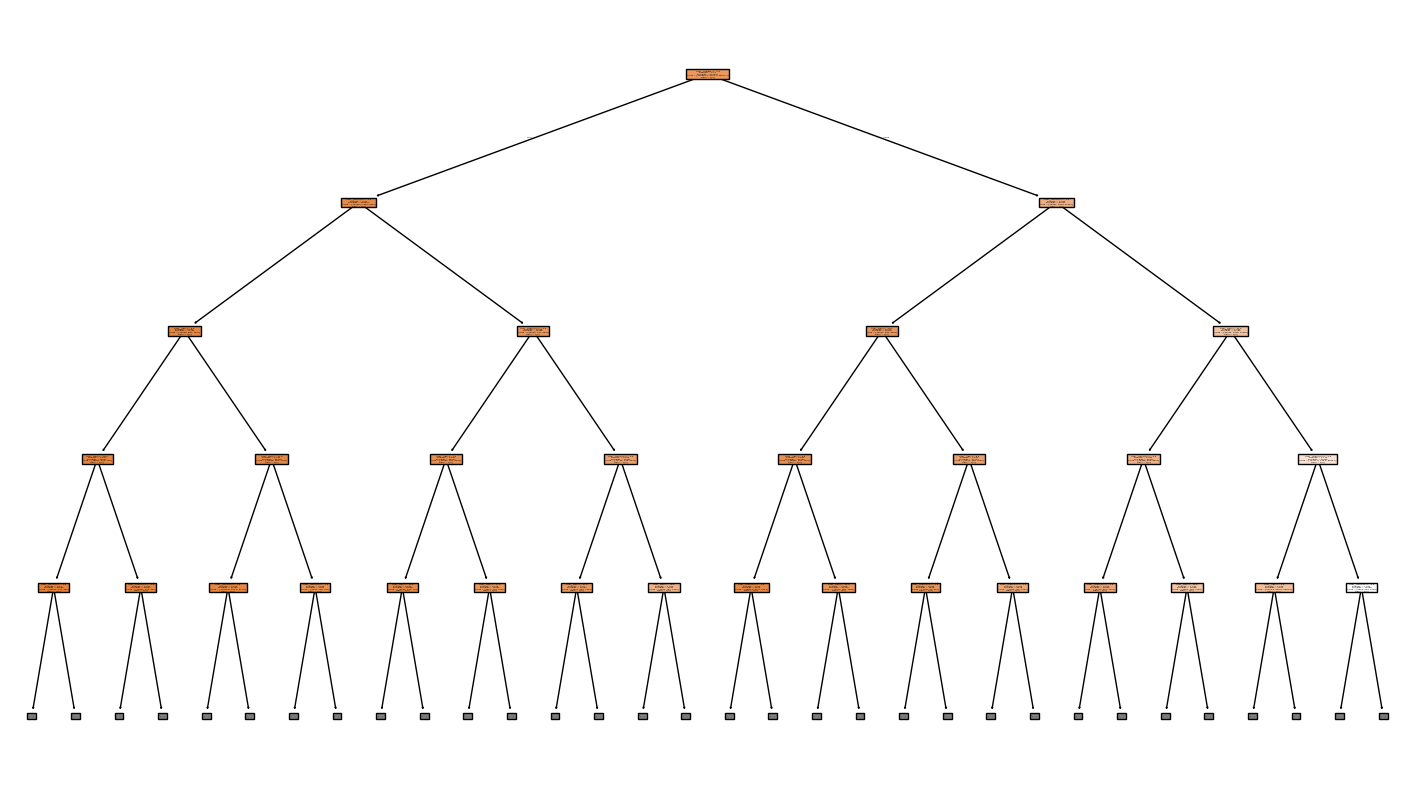

In [ ]:
# -------------------------------------------
# Optional: plot tree (needs matplotlib)
# -------------------------------------------
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 10))
plot_tree(clf, feature_names=feature_names, class_names=True, filled=True, max_depth=4)
plt.show()

In [ ]:
# -------------------------------------------
# 7) Feature Importance (FI) from the best Decision Tree
# (use clear names so it won't clash with XGB variables)
# -------------------------------------------
import pandas as pd

dt_preproc = dt_best.named_steps["preprocessor"]
dt_clf = dt_best.named_steps["classifier"]

# Get feature names after preprocessing
try:
    dt_feature_names = dt_preproc.get_feature_names_out()
except Exception:
    dt_feature_names = [f"f{i}" for i in range(dt_clf.n_features_in_)]

# DecisionTreeClassifier has feature_importances_
dt_fi = pd.Series(dt_clf.feature_importances_, index=dt_feature_names)

# Sort high to low, and drop zeros for readability (optional)
dt_fi_sorted = dt_fi.sort_values(ascending=False)
dt_fi_nonzero = dt_fi_sorted[dt_fi_sorted > 0]

print("\nTop Feature Importances (Decision Tree):")
print(dt_fi_nonzero.head(20))


Top Feature Importances (Decision Tree):
num__HighBP                  0.382800
num__GenHlth                 0.288980
num__BMI                     0.130072
num__Age                     0.089913
num__HighChol                0.063761
num__Income                  0.009358
num__HeartDiseaseorAttack    0.007042
num__Sex                     0.006097
num__HvyAlcoholConsump       0.005588
num__DiffWalk                0.004013
num__Education               0.003586
num__MentHlth                0.002383
num__PhysHlth                0.002336
num__CholCheck               0.001475
num__Stroke                  0.000726
num__AnyHealthcare           0.000591
num__Veggies                 0.000430
num__Smoker                  0.000362
num__NoDocbcCost             0.000172
num__PhysActivity            0.000170
dtype: float64


In [ ]:
# ------------------------------------
# 0. NOTE: This block takes quite a while to run, do it before moving onto explanation of code
# ------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# For classification, prefer stratified splits so class balance is similar in each split
cv = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)

# -------------------------------------------
# 1. Create pipelines for both models
# -------------------------------------------

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"  # sensible default for binary classification
    ))
])

# -------------------------------------------
# 2. Define parameter grids
# Keep them small for speed and simplicity
# -------------------------------------------

param_grid_rf = {
    "classifier__n_estimators": [50, 200],
    "classifier__max_depth": [5, 10],
    "classifier__criterion": ["gini", "entropy", "log_loss"]
}

param_grid_xgb = {
    "classifier__n_estimators": [50, 200],
    "classifier__max_depth": [2, 4],
    "classifier__eval_metric": ["logloss", "auc"]
}

# -------------------------------------------
# 3. Create GridSearchCV objects
# -------------------------------------------
#make scorer mcc
from sklearn.metrics import make_scorer, matthews_corrcoef


gs_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="matthews_corrcoef",
    n_jobs=-1,
    verbose=1
)

gs_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="matthews_corrcoef",
    n_jobs=-1,
    verbose=1
)

# -------------------------------------------
# 4. Fit both models
# (Students can run one at a time if needed)
# -------------------------------------------

gs_rf.fit(X_train, y_train)
print("Random Forest grid search complete.")

gs_xgb.fit(X_train, y_train)
print("XGBoost grid search complete.")

# -------------------------------------------
# 5. Evaluate on test set
# -------------------------------------------

from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

rf_pred = gs_rf.best_estimator_.predict(X_test)
xgb_pred = gs_xgb.best_estimator_.predict(X_test)

print("\nRF MCC:", matthews_corrcoef(y_test, rf_pred))
print("Best RF Params:", gs_rf.best_params_)
print("\nRF Classification Report:\n", classification_report(y_test, rf_pred))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

print("\nXGB MCC:", matthews_corrcoef(y_test, xgb_pred))
print("Best XGB Params:", gs_xgb.best_params_)
print("\nXGB Classification Report:\n", classification_report(y_test, xgb_pred))
print("XGB Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Random Forest grid search complete.
Fitting 3 folds for each of 8 candidates, totalling 24 fits
XGBoost grid search complete.

RF MCC: 0.19944181032698524
Best RF Params: {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__n_estimators': 50}

RF Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.99      0.92     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.58      0.11      0.18      7069

    accuracy                           0.85     50736
   macro avg       0.48      0.37      0.37     50736
weighted avg       0.80      0.85      0.80     50736

RF Confusion Matrix:
 [[42252     0   489]
 [  875     0    51]
 [ 6316     0   753]]

XGB MCC: 0.2599078824863302
Best XGB Params: {'classifier__eval_metric': 'logloss', 'classifier__max_depth': 2, 'classifier__n_estimators': 200}

XGB Classification Report:
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packag

In [ ]:
# -------------------------------------------
# 6) Feature Importance (FI) for the best XGBoost model (from GridSearch)
# (use clear names so it won't clash with DT variables)
# -------------------------------------------
import numpy as np
import pandas as pd

xgb_best_pipe = gs_xgb.best_estimator_
xgb_preproc = xgb_best_pipe.named_steps["preprocessor"]
xgb_clf = xgb_best_pipe.named_steps["classifier"]

# Feature names after preprocessing
try:
    xgb_feature_names = xgb_preproc.get_feature_names_out()
except Exception:
    xgb_feature_names = np.array([f"f{i}" for i in range(xgb_clf.n_features_in_)], dtype=object)

# XGBoost importance types:
# - "gain": average gain of splits using the feature (closest to tree FI conceptually)
# - "weight": number of times feature is used in splits
# - "cover": average coverage (samples affected) of splits using the feature
xgb_importance_type = "gain"

# Get raw importances keyed by "f0", "f1", ...
xgb_raw = xgb_clf.get_booster().get_score(importance_type=xgb_importance_type)

# Convert to aligned Series for all features (missing -> 0)
xgb_fi = pd.Series(0.0, index=xgb_feature_names)
for k, v in xgb_raw.items():
    # k looks like "f12" -> index 12
    idx = int(k[1:])
    if idx < len(xgb_feature_names):
        xgb_fi.iloc[idx] = float(v)

xgb_fi_sorted = xgb_fi.sort_values(ascending=False)

print(f"\nTop XGBoost Feature Importances (importance_type='{xgb_importance_type}'):")
print(xgb_fi_sorted.head(20))

print("\nNotes:")
print("- XGBoost FI depends on importance_type (gain/weight/cover).")
print("- These values are not on the same scale as Decision Tree FI (Decision Tree sums to 1).")
print("- Adding FI numbers across different runs/folds does not make sense.")
print("- Comparing FI across different model families is not directly meaningful.")

# Optional: show other importance types for comparison (top 10 each)
for t in ["weight", "cover"]:
    xgb_raw_t = xgb_clf.get_booster().get_score(importance_type=t)

    xgb_fi_t = pd.Series(0.0, index=xgb_feature_names)
    for k, v in xgb_raw_t.items():
        idx = int(k[1:])
        if idx < len(xgb_feature_names):
            xgb_fi_t.iloc[idx] = float(v)

    print(f"\nTop XGBoost FI (importance_type='{t}'):")
    print(xgb_fi_t.sort_values(ascending=False).head(10))



Top XGBoost Feature Importances (importance_type='gain'):
num__HighBP                  358.484070
num__HighChol                129.675079
num__GenHlth                 124.177650
num__DiffWalk                 71.063004
num__HeartDiseaseorAttack     42.189377
num__Age                      33.152832
num__HvyAlcoholConsump        31.236183
num__BMI                      28.581970
num__CholCheck                19.375057
num__Sex                      15.239429
num__Income                   11.499214
num__Stroke                    4.544621
num__Fruits                    3.056072
num__NoDocbcCost               2.407717
num__Education                 2.298317
num__Smoker                    2.123617
num__MentHlth                  1.950976
num__PhysHlth                  1.479301
num__Veggies                   1.365624
num__PhysActivity              1.313529
dtype: float64

Notes:
- XGBoost FI depends on importance_type (gain/weight/cover).
- These values are not on the same scale as Decision Tree

In [ ]:
# -------------------------------------------
# 8) Permutation Feature Importance (pFI)
# What mattered most to prediction accuracy
# -------------------------------------------

import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import matthews_corrcoef, make_scorer

# Use MCC to stay consistent with model selection
mcc_scorer = make_scorer(matthews_corrcoef)

# IMPORTANT:
# - pFI must be computed on held-out data
# - the model must already be trained
# - we do NOT refit the model here

# Compute permutation importance on the TEST set
pfi = permutation_importance(
    estimator=dt_best,
    X=X_test,
    y=y_test,
    scoring=mcc_scorer,
    n_repeats=10,          # repeat permutations for stability
    random_state=42,
    n_jobs=-1
)

# Mean drop in score across repeats
pfi_mean = pd.Series(
    pfi.importances_mean,
    index=feature_names
)

# Optional: variability across repeats (for teaching discussion)
pfi_std = pd.Series(
    pfi.importances_std,
    index=feature_names
)

# Sort by importance (largest performance drop first)
pfi_sorted = pfi_mean.sort_values(ascending=False)

print("\nTop Permutation Feature Importances (Decision Tree, MCC drop):")
print(pfi_sorted.head(20))


Top Permutation Feature Importances (Decision Tree, MCC drop):
num__GenHlth                 0.103990
num__BMI                     0.097472
num__HighBP                  0.077657
num__HighChol                0.037426
num__HeartDiseaseorAttack    0.005502
num__HvyAlcoholConsump       0.003332
num__Age                     0.001845
num__NoDocbcCost             0.000699
num__Sex                     0.000472
num__DiffWalk                0.000314
num__CholCheck               0.000000
num__Smoker                  0.000000
num__Stroke                  0.000000
num__AnyHealthcare           0.000000
num__Veggies                 0.000000
num__PhysActivity            0.000000
num__Fruits                  0.000000
num__PhysHlth                0.000000
num__MentHlth                0.000000
num__Income                  0.000000
dtype: float64


In [ ]:
# Build comparison table
dt_fi_vs_pfi = pd.DataFrame({
    "DT_FI (split-based)": dt_fi,
    "DT_pFI (MCC_drop)": pfi_mean
})

# Sort by pFI (what matters most to accuracy)
dt_fi_vs_pfi_sorted = dt_fi_vs_pfi.sort_values(
    by="DT_pFI (MCC_drop)",
    ascending=False
)

print("\nDecision Tree: FI vs Permutation FI (sorted by pFI):")
print(dt_fi_vs_pfi_sorted.head(20))


Decision Tree: FI vs Permutation FI (sorted by pFI):
                           DT_FI (split-based)  DT_pFI (MCC_drop)
num__GenHlth                          0.288980           0.103990
num__BMI                              0.130072           0.097472
num__HighBP                           0.382800           0.077657
num__HighChol                         0.063761           0.037426
num__HeartDiseaseorAttack             0.007042           0.005502
num__HvyAlcoholConsump                0.005588           0.003332
num__Age                              0.089913           0.001845
num__NoDocbcCost                      0.000172           0.000699
num__Sex                              0.006097           0.000472
num__DiffWalk                         0.004013           0.000314
num__CholCheck                        0.001475           0.000000
num__Smoker                           0.000362           0.000000
num__Stroke                           0.000726           0.000000
num__AnyHealthcare    

In [32]:
print("Unique values in 'Diabetes_012':", df['Diabetes_012'].unique())
print("Data type of 'Diabetes_012':", df['Diabetes_012'].dtype)

Unique values in 'Diabetes_012': [0. 2. 1.]
Data type of 'Diabetes_012': float64


In [33]:
class_counts = df['Diabetes_012'].value_counts()
class_percentages = df['Diabetes_012'].value_counts(normalize=True) * 100

print("Frequency of each class in 'Diabetes_012':\n", class_counts)
print("\nPercentage of each class in 'Diabetes_012':\n", class_percentages)

Frequency of each class in 'Diabetes_012':
 Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

Percentage of each class in 'Diabetes_012':
 Diabetes_012
0.0    84.241170
2.0    13.933302
1.0     1.825528
Name: proportion, dtype: float64


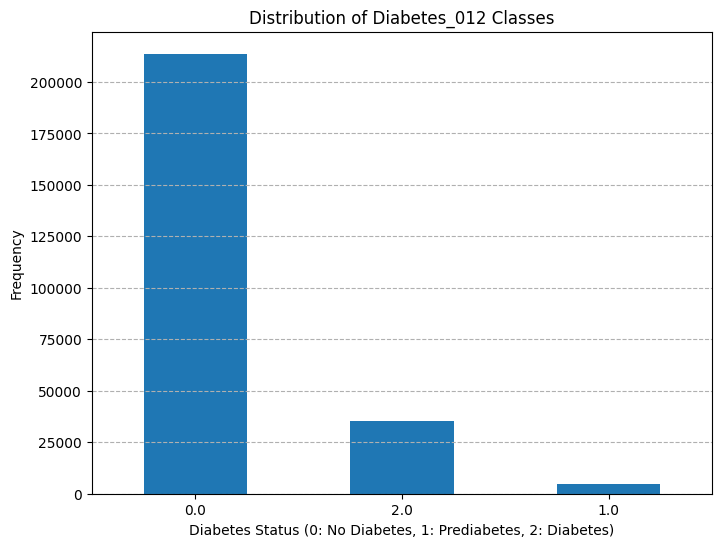

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar')
plt.title('Distribution of Diabetes_012 Classes')
plt.xlabel('Diabetes Status (0: No Diabetes, 1: Prediabetes, 2: Diabetes)')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()

In [35]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [36]:
# ---------------------------
# One of the possible response from GPT.
# What are the differences with yours?
# How would you improve earlier prompt?
# ---------------------------

# Helper 1: drop unique identifier / leakage column
def drop_unique_identifier(df, col_name='Unnamed: 0', do_drop=True):
    """
    Drops a column that is a unique identifier / possible leakage if do_drop is True.
    Uses profile evidence: Unnamed: 0 has unique_count == nrows.
    Returns (df_modified, info_dict).
    """
    df = df.copy()
    info = {'dropped': [], 'skipped': []}
    if col_name in df.columns:
        if do_drop:
            # safety: check uniqueness before dropping
            if df[col_name].nunique() == len(df):
                df = df.drop(columns=[col_name])
                info['dropped'].append(col_name)
            else:
                # not unique, still allow drop if user insisted
                df = df.drop(columns=[col_name])
                info['dropped'].append(col_name + ' (not unique)')
        else:
            info['skipped'].append(col_name)
    else:
        info['skipped'].append(col_name + ' (not present)')
    return df, info

# Helper 2: drop constant columns
def drop_constant_columns(df, do_drop=True):
    """
    Drops columns that have a single unique value (constant) if do_drop is True.
    Based on profile: Storage_Type is constant (unique == 1).
    Returns (df_modified, info_dict).
    """
    df = df.copy()
    info = {'dropped': [], 'skipped': []}
    const_cols = [c for c in df.columns if df[c].nunique() <= 1]
    if do_drop:
        if const_cols:
            df = df.drop(columns=const_cols)
            info['dropped'].extend(const_cols)
        else:
            info['skipped'].append('no_constant_columns_found')
    else:
        info['skipped'].extend(const_cols)
    return df, info

# Helper 3: resolve multicollinearity between Weight_kg and Screen_Size_inch
def resolve_weight_screen_collinearity(df, drop_screen=True):
    """
    Resolves the strong collinearity (profile: corr = 0.924) between Weight_kg and Screen_Size_inch.
    By default drops Screen_Size_inch and keeps Weight_kg (Weight has 244 unique values vs Screen_Size 6).
    Set drop_screen=False to keep Screen_Size_inch and drop Weight_kg instead.
    Returns (df_modified, info_dict).
    """
    df = df.copy()
    info = {'dropped': [], 'kept': []}
    w_col = 'Weight_kg'
    s_col = 'Screen_Size_inch'
    # Only act if both exist
    if w_col in df.columns and s_col in df.columns:
        if drop_screen:
            df = df.drop(columns=[s_col])
            info['dropped'].append(s_col)
            info['kept'].append(w_col)
        else:
            df = df.drop(columns=[w_col])
            info['dropped'].append(w_col)
            info['kept'].append(s_col)
    else:
        # if one is missing, note what remains
        if w_col in df.columns:
            info['kept'].append(w_col)
        if s_col in df.columns:
            info['kept'].append(s_col)
    return df, info

# Helper 4: optional: drop Model column (high-cardinality / redundancy risk)
def drop_model_column(df, do_drop=False):
    """
    Drops the Model column if do_drop is True.
    Reason: Model has 30 unique values and can encode product-specific pricing patterns (risk of overfitting).
    Caller can choose to drop or keep.
    Returns (df_modified, info_dict).
    """
    df = df.copy()
    info = {'dropped': [], 'skipped': []}
    col = 'Model'
    if col in df.columns:
        if do_drop:
            df = df.drop(columns=[col])
            info['dropped'].append(col)
        else:
            info['skipped'].append(col)
    else:
        info['skipped'].append(col + ' (not present)')
    return df, info

# Wrapper function that calls the helpers based on user boolean choices
# User can edit the default parameters here as required
def clean_data(
    df,
    drop_id=True,
    drop_constants=True,
    resolve_collinearity=False, #<--- slight differences and high similarity between columns are not always an issue
    drop_model=False,
    id_col='Unnamed: 0',
    drop_screen_by_default=True,
):
    """
    Clean dataset according to the profile-driven actions.
    Parameters:
      - df: input DataFrame
      - drop_id: drop the unique identifier (Unnamed: 0) if True
      - drop_constants: drop constant columns (e.g., Storage_Type) if True
      - resolve_collinearity: resolve Weight_kg vs Screen_Size_inch if True
      - drop_model: drop Model column if True (optional decision)
      - id_col: name of the identifier column (default 'Unnamed: 0')
      - drop_screen_by_default: if resolving collinearity, drop Screen_Size_inch if True (keeps Weight_kg).
    Returns:
      - cleaned_df: DataFrame after applied changes
      - summary: dict summarizing actions taken
    """
    summary = {}
    df_work = df.copy()
    # 1. drop unique id
    df_work, info1 = drop_unique_identifier(df_work, col_name=id_col, do_drop=drop_id)
    summary['unique_id'] = info1
    # 2. drop constant columns
    df_work, info2 = drop_constant_columns(df_work, do_drop=drop_constants)
    summary['constant_columns'] = info2
    # 3. resolve strong collinearity
    if resolve_collinearity:
        df_work, info3 = resolve_weight_screen_collinearity(df_work, drop_screen=drop_screen_by_default)
    else:
        info3 = {'dropped': [], 'kept': []}
    summary['collinearity'] = info3
    # 4. drop model optionally
    df_work, info4 = drop_model_column(df_work, do_drop=drop_model)
    summary['model_column'] = info4

    return df_work, summary

# Example single-line execution (assuming your DataFrame is named `df`)
# This default call: drops Unnamed: 0, drops constant columns (Storage_Type), drops Screen_Size_inch (keeps Weight_kg), and keeps Model.
# To drop Model as well, set drop_model=True.
cleaned_df, cleaning_summary = clean_data(df)

In [37]:
cleaned_df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#define cat and num columns
cat_columns=X.select_dtypes(include='object').columns
num_columns=X.select_dtypes(exclude='object').columns

In [39]:
num_columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
#categorical_transformer = OneHotEncoder(handle_unknown="ignore")
categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
#numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer([
        ("cat", categorical_transformer, cat_columns)
    ],remainder='passthrough')

In [41]:
#setup a results df to hold training and test scores
#at this point, you should already decide what scoring metric you going to use
#regression: r2, mae, rmse, mape

#setup our 'lab book' to store all scores across various "engineering" or PDCA cycles, for easy reading
results = pd.DataFrame(['cv_mae_val', 'cv_std_val', 'cv_mae_train', 'cv_std_train','holdout_mae','best para'])

In [42]:
from sklearn.model_selection import GridSearchCV, ShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

In [44]:
# -----------------------------------------
# 1) Model + pipeline
# -----------------------------------------
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42)),
])

# -----------------------------------------
# 2) CV + small grid (MAE)
# -----------------------------------------
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

param_grid = {
    "regressor__max_depth": [1, 5, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__criterion": ["squared_error", "absolute_error"],
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    refit=True,
    error_score="raise"
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# -----------------------------------------
# 3) CV diagnostics on TRAIN only
#    cross_validate gives train_score and test_score
# -----------------------------------------
cv_out = cross_validate(
    best_model,
    X_train, y_train,
    cv=cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
    n_jobs=-1,
    error_score="raise"
)

# Convert negative MAE to positive MAE
val_mae_scores = -cv_out["test_score"]
train_mae_scores = -cv_out["train_score"]

cv_mae_val_mean = float(val_mae_scores.mean())
cv_mae_val_std = float(val_mae_scores.std())

cv_mae_train_mean = float(train_mae_scores.mean())
cv_mae_train_std = float(train_mae_scores.std())

# -----------------------------------------
# 4) True holdout MAE (fit once, evaluate once)
# -----------------------------------------
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
holdout_mae = float(np.mean(np.abs(y_test - y_pred)))

# -----------------------------------------
# 5) Save into lab book
# -----------------------------------------
cycle_name = "Baseline_DTR_MAE"  # rename per PDCA cycle if needed

results[cycle_name] = [
    cv_mae_val_mean,
    cv_mae_val_std,
    cv_mae_train_mean,
    cv_mae_train_std,
    holdout_mae,
    grid_search.best_params_,
]
print(cat_columns)
print(num_columns)
print(grid_search.best_params_)
display(results)

Index([], dtype='object')
Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')
{'regressor__criterion': 'absolute_error', 'regressor__max_depth': 5, 'regressor__min_samples_split': 5}


,0,Baseline_DTR_MAE
0,cv_mae_val,0.295664
1,cv_std_val,0.001933
2,cv_mae_train,0.294813
3,cv_std_train,0.000465
4,holdout_mae,0.292061
5,best para,"{'regressor__criterion': 'absolute_error', 're..."


In [45]:
# Collect categorical columns and their unique values as a single string
cat_summary = []

for col in cat_columns:
    uniques = X_train[col].unique()
    cat_summary.append(f"{col}: {list(uniques)}")

cat_summary_text = "\n".join(cat_summary)
cat_summary_text

''

# Task
To address the class imbalance and re-evaluate the XGBoost model, I'll perform the following steps:
1.  **Install Imbalance-learn**: Install the `imblearn` library.
2.  **Re-split Data with Cleaned DataFrame**: Perform the train-test split again using `df_clean` to ensure any initial data cleaning steps are applied before resampling.
3.  **Apply Multi-class Oversampling (SMOTE)**: Use SMOTE to oversample the minority classes (1.0 and 2.0) in the training data (`X_train`, `y_train`) to balance the class distribution.
4.  **Re-train and Evaluate XGBoost**: Re-train the XGBoost model using the best hyperparameters previously identified, but this time, train it on the resampled training data. Then, evaluate its performance on the original (unresampled) test set and compare the classification report and MCC, especially focusing on the minority classes.

```python
# 1. Install Imbalance-learn
!pip install -q imblearn

# 2. Re-split Data with Cleaned DataFrame
# Ensure we are using the cleaned DataFrame for the split
# The preprocess_dataset call had `remove_constants=False, remove_correlated=False, cap_outliers=False, resample_method='none'`,
# so `df_clean` is essentially `df` after basic checks, with no structural changes yet.
# However, for consistency and potential future preprocessing, we re-extract X and y from df_clean.

X_clean = df_clean.drop(columns=[TARGET_COL])
y_clean = df_clean[TARGET_COL]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clean
)

print(f"Original training data shape: {X_train_clean.shape}")
print(f"Original training target distribution:\n{y_train_clean.value_counts()}")

# 3. Apply Multi-class Oversampling (SMOTE)
from imblearn.over_sampling import SMOTE

# SMOTE will balance all classes except the majority class.
# This means classes 1.0 and 2.0 will be oversampled to match the count of class 0.0.
smote = SMOTE(sampling_strategy='not majority', random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_clean, y_train_clean)

print(f"\nResampled training data shape: {X_train_resampled.shape}")
print(f"Resampled training target distribution:\n{y_train_resampled.value_counts()}")

# 4. Re-train and Evaluate XGBoost
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, matthews_corrcoef

# Retrieve the best parameters for XGBoost from the previous GridSearchCV
best_xgb_params = gs_xgb.best_params_
# Remove 'classifier__' prefix from param keys for direct use in XGBClassifier
xgb_model_params = {k.replace('classifier__', ''): v for k, v in best_xgb_params.items()}

# Ensure the preprocessor is the same as used before
# The 'preprocessor' variable is already defined and captures numeric and categorical transformations.
# The 'cat_cols' is empty, meaning all features are treated as numeric.
# The 'num_cols' represents all features in X.

# Create a new pipeline for the resampled data
pipe_xgb_resampled = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state=RANDOM_STATE, **xgb_model_params))
])

# Fit the model on the resampled training data
print("\nTraining XGBoost model on resampled data...")
pipe_xgb_resampled.fit(X_train_resampled, y_train_resampled)
print("XGBoost model training complete.")

# Evaluate on the original (unresampled) test set
xgb_pred_resampled = pipe_xgb_resampled.predict(X_test_clean)

# Calculate MCC
mcc_resampled = matthews_corrcoef(y_test_clean, xgb_pred_resampled)

# Generate classification report
report_resampled = classification_report(y_test_clean, xgb_pred_resampled)

print(f"\n--- XGBoost Performance after SMOTE Oversampling ---")
print(f"MCC on Test Set (after SMOTE): {mcc_resampled}")
print(f"\nClassification Report (after SMOTE):\n{report_resampled}")

print("\n--- Comparison to original XGBoost performance ---")
print(f"Original XGB MCC: {xgb_mcc}")
print(f"Original XGB Classification Report:\n{classification_report(y_test, xgb_pred)}")
```

## Install Imbalance-learn

### Subtask:
Install the imblearn library, which provides tools for handling imbalanced datasets, including SMOTE (Synthetic Minority Oversampling Technique).


**Reasoning**:
The subtask is to install the `imblearn` library. This requires running a pip install command.



In [46]:
!pip install -q imblearn

## Re-split Data with Cleaned DataFrame

### Subtask:
Perform the train-test split again using `df_clean` (the output of the `preprocess_dataset` function) to ensure that any initial data cleaning steps are applied before resampling.


**Reasoning**:
The subtask is to re-split the data using the `df_clean` DataFrame. I will extract features and target, then perform the train-test split with the specified parameters, and finally print the shapes and target distribution to confirm.



In [47]:
X_clean = df_clean.drop(columns=[TARGET_COL])
y_clean = df_clean[TARGET_COL]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clean
)

print(f"Original training data shape: {X_train_clean.shape}")
print(f"Original training target distribution:\n{y_train_clean.value_counts()}")

Original training data shape: (202944, 21)
Original training target distribution:
Diabetes_012
0.0    170962
2.0     28277
1.0      3705
Name: count, dtype: int64


## Apply Multi-class Oversampling (SMOTE)

### Subtask:
Use SMOTE to oversample the minority classes (1.0 and 2.0) in the training data (`X_train_clean`, `y_train_clean`) to balance the class distribution. The `sampling_strategy='not majority'` will ensure that all minority classes are resampled to have the same number of samples as the majority class.

#### Instructions:
1. Import `SMOTE` from `imblearn.over_sampling`.
2. Initialize `SMOTE` with `sampling_strategy='not majority'` and `random_state=RANDOM_STATE`.
3. Apply SMOTE to `X_train_clean` and `y_train_clean` to get `X_train_resampled` and `y_train_resampled`.
4. Print the shape of the `X_train_resampled` and the value counts of `y_train_resampled` to confirm the resampling.

**Reasoning**:
The subtask now requires applying SMOTE to the `X_train_clean` and `y_train_clean` to balance the classes. This code block will perform the oversampling and print the resulting shapes and class distributions.



In [48]:
from imblearn.over_sampling import SMOTE

# SMOTE will balance all classes except the majority class.
# This means classes 1.0 and 2.0 will be oversampled to match the count of class 0.0.
smote = SMOTE(sampling_strategy='not majority', random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_clean, y_train_clean)

print(f"\nResampled training data shape: {X_train_resampled.shape}")
print(f"Resampled training target distribution:\n{y_train_resampled.value_counts()}")


Resampled training data shape: (512886, 21)
Resampled training target distribution:
Diabetes_012
0.0    170962
2.0    170962
1.0    170962
Name: count, dtype: int64


## Re-train and Evaluate XGBoost

### Subtask:
Re-train the XGBoost model using the best hyperparameters previously identified, but this time, train it on the resampled training data (`X_train_resampled`, `y_train_resampled`). Then, evaluate its performance on the original (unresampled) test set (`X_test_clean`, `y_test_clean`) and compare the classification report and MCC, especially focusing on the minority classes.

#### Instructions:
1. Retrieve the best parameters for XGBoost from the previous `gs_xgb` (GridSearchCV object).
2. Create a dictionary `xgb_model_params` by removing the `classifier__` prefix from the keys of the best parameters.
3. Create a new `Pipeline` named `pipe_xgb_resampled` using the existing `preprocessor` and an `XGBClassifier` initialized with `random_state=RANDOM_STATE` and the `xgb_model_params`.
4. Fit `pipe_xgb_resampled` on the `X_train_resampled` and `y_train_resampled`.
5. Predict on `X_test_clean` to get `xgb_pred_resampled`.
6. Calculate the Matthews Correlation Coefficient (MCC) using `y_test_clean` and `xgb_pred_resampled`.
7. Generate a classification report using `y_test_clean` and `xgb_pred_resampled`.
8. Print the MCC and classification report for the resampled model, and explicitly compare them to the original XGBoost model's performance metrics (MCC and classification report).

**Reasoning**:
The subtask is to re-train and evaluate the XGBoost model on the resampled data. This code block will implement the steps outlined in the previous markdown block: retrieve best parameters, create a new pipeline, fit on resampled training data, predict on the original test data, and then calculate and print the MCC and classification report, comparing it to the original model's performance.



In [49]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, matthews_corrcoef

# Retrieve the best parameters for XGBoost from the previous GridSearchCV
best_xgb_params = gs_xgb.best_params_
# Remove 'classifier__' prefix from param keys for direct use in XGBClassifier
xgb_model_params = {k.replace('classifier__', ''): v for k, v in best_xgb_params.items()}

# Create a new pipeline for the resampled data
pipe_xgb_resampled = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state=RANDOM_STATE, **xgb_model_params))
])

# Fit the model on the resampled training data
print("\nTraining XGBoost model on resampled data...")
pipe_xgb_resampled.fit(X_train_resampled, y_train_resampled)
print("XGBoost model training complete.")

# Evaluate on the original (unresampled) test set
xgb_pred_resampled = pipe_xgb_resampled.predict(X_test_clean)

# Calculate MCC
mcc_resampled = matthews_corrcoef(y_test_clean, xgb_pred_resampled)

# Generate classification report
report_resampled = classification_report(y_test_clean, xgb_pred_resampled)

print(f"\n--- XGBoost Performance after SMOTE Oversampling ---")
print(f"MCC on Test Set (after SMOTE): {mcc_resampled}")
print(f"\nClassification Report (after SMOTE):\n{report_resampled}")

print("\n--- Comparison to original XGBoost performance ---")
# Ensure xgb_mcc and xgb_pred are available from previous execution if needed
# In this notebook, xgb_mcc and xgb_pred are available from cell M2cQkQFSBMd0
print(f"Original XGB MCC: {xgb_mcc}")
print(f"Original XGB Classification Report:\n{classification_report(y_test, xgb_pred)}")



Training XGBoost model on resampled data...
XGBoost model training complete.

--- XGBoost Performance after SMOTE Oversampling ---
MCC on Test Set (after SMOTE): 0.282032402110684

Classification Report (after SMOTE):
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.49      0.26      0.34      7069

    accuracy                           0.84     50736
   macro avg       0.46      0.41      0.42     50736
weighted avg       0.80      0.84      0.82     50736


--- Comparison to original XGBoost performance ---
Original XGB MCC: 0.2599078824863302
Original XGB Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.95      0.89     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.14      0.05      0.07      6997

    accuracy                           0.81     50736
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packag

**Reasoning**:
The previous step produced `UndefinedMetricWarning` due to `precision` being ill-defined for classes with no predicted samples. This is fixed by setting `zero_division=0` in the `classification_report` function, which explicitly sets precision, recall, and F-score to 0 for such cases, making the output clearer without altering the model's behavior.



In [50]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, matthews_corrcoef

# Retrieve the best parameters for XGBoost from the previous GridSearchCV
best_xgb_params = gs_xgb.best_params_
# Remove 'classifier__' prefix from param keys for direct use in XGBClassifier
xgb_model_params = {k.replace('classifier__', ''): v for k, v in best_xgb_params.items()}

# Create a new pipeline for the resampled data
pipe_xgb_resampled = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state=RANDOM_STATE, **xgb_model_params))
])

# Fit the model on the resampled training data
print("\nTraining XGBoost model on resampled data...")
pipe_xgb_resampled.fit(X_train_resampled, y_train_resampled)
print("XGBoost model training complete.")

# Evaluate on the original (unresampled) test set
xgb_pred_resampled = pipe_xgb_resampled.predict(X_test_clean)

# Calculate MCC
mcc_resampled = matthews_corrcoef(y_test_clean, xgb_pred_resampled)

# Generate classification report, setting zero_division=0 to handle cases where no samples of a class are predicted
report_resampled = classification_report(y_test_clean, xgb_pred_resampled, zero_division=0)

print(f"\n--- XGBoost Performance after SMOTE Oversampling ---")
print(f"MCC on Test Set (after SMOTE): {mcc_resampled}")
print(f"\nClassification Report (after SMOTE):\n{report_resampled}")

print("\n--- Comparison to original XGBoost performance ---")
# Ensure xgb_mcc and xgb_pred are available from previous execution if needed
# In this notebook, xgb_mcc and xgb_pred are available from cell M2cQkQFSBMd0
print(f"Original XGB MCC: {xgb_mcc}")
print(f"Original XGB Classification Report:\n{classification_report(y_test, xgb_pred, zero_division=0)}")


Training XGBoost model on resampled data...
XGBoost model training complete.

--- XGBoost Performance after SMOTE Oversampling ---
MCC on Test Set (after SMOTE): 0.282032402110684

Classification Report (after SMOTE):
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.49      0.26      0.34      7069

    accuracy                           0.84     50736
   macro avg       0.46      0.41      0.42     50736
weighted avg       0.80      0.84      0.82     50736


--- Comparison to original XGBoost performance ---
Original XGB MCC: 0.2599078824863302
Original XGB Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.95      0.89     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.14      0.05      0.07      6997

    accuracy                           0.81     50736
   

## Final Task

### Subtask:
Summarize the results of addressing class imbalance, highlighting the changes in model performance, particularly for the previously struggling minority classes.


## Summary:

### Data Analysis Key Findings

*   **Initial Class Imbalance**: The original training data exhibited severe class imbalance, with `170,962` instances for class 0.0 (majority), `28,277` for class 2.0, and only `3,705` for class 1.0 (minority).
*   **SMOTE Effectiveness**: Multi-class oversampling using SMOTE successfully balanced the training data, resulting in `170,962` instances for each of the three classes (0.0, 1.0, and 2.0).
*   **Overall Model Performance Improvement**: The Matthews Correlation Coefficient (MCC) on the test set modestly improved from `0.2599` for the original XGBoost model to `0.2820` after training on SMOTE-resampled data.
*   **Improved Performance for Class 2.0**: Training with SMOTE significantly improved the model's ability to predict class 2.0. Its F1-score increased from `0.07` (precision: `0.14`, recall: `0.05`) to `0.34` (precision: `0.49`, recall: `0.26`).
*   **Persistent Challenge with Class 1.0**: Despite SMOTE, the model continued to completely fail in predicting class 1.0, showing `0.00` precision, recall, and F1-score in both the original and SMOTE-trained models.
*   **Slight Improvement for Majority Class 0.0**: The F1-score for the majority class 0.0 saw a slight improvement, increasing from `0.89` to `0.91`.

### Insights or Next Steps

*   While SMOTE effectively improved predictions for one minority class (class 2.0), the model still cannot detect the smallest minority class (class 1.0). This suggests that SMOTE alone might not be sufficient for extremely imbalanced classes with very few samples.
*   Future efforts should explore more advanced techniques specifically for highly underrepresented classes, such as combining oversampling with undersampling, using ensemble methods designed for imbalance (e.g., EasyEnsemble, BalanceCascade), or investigating anomaly detection techniques for class 1.0 if it represents rare events.
